# 07 - model testing

## 07.2 - 1d cnn on log-mel-spectrograms

**purpose**: final production-readiness check for the lightweight 1d cnn on the **held-out test set** (speakers 23-24, never seen during training or validation). reports test accuracy, per-emotion breakdown, and per-sample cpu inference latency (the deployment target).

**input**: `data/processed/X_test_mel.npy`, `y_test.npy`, `data/models/cnn1d_best.pth`

**output**: `data/predictions/test_results_cnn.json` (consumed by 08)

In [1]:
import sys
sys.path.append("../../")

**import testing modules**. json, numpy, matplotlib, sklearn metrics, and cnn model helpers.

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from src.config.config import settings
from src.models.cnn1d_model import load_cnn, predict_cnn, count_parameters, cpu_inference_latency

## Load saved model

In [3]:
device = settings.TORCH_DEVICE
model = load_cnn(settings.MODELS_DIR / "cnn1d_best.pth", device=device)

**confirm model loaded**. print the parameter count.

In [4]:
params = count_parameters(model)
print(f"Model loaded: {params:,} parameters")

Model loaded: 132,806 parameters


## Load test data and run inference

In [5]:
X_test = np.load(settings.PROCESSED_DIR / "X_test_mel.npy")
y_test = np.load(settings.PROCESSED_DIR / "y_test.npy")

**verify test data**. confirm shape and speakers.

In [6]:
print(f"Test samples: {X_test.shape[0]}  (speakers {settings.TEST_ACTORS})")
assert X_test.shape[1:] == (settings.N_MELS, settings.N_MELS_FRAMES), (
    f"expected mel shape ({settings.N_MELS}, {settings.N_MELS_FRAMES}), got {X_test.shape[1:]}"
)

Test samples: 176  (speakers [23, 24])


**run inference on test set**. the cnn achieves 66.48% on the held-out test set. notably, this is lower than the svm's test accuracy (70.45%), suggesting the cnn may have overfit to the training speakers more than the svm.

In [7]:
test_preds, _ = predict_cnn(model, X_test, batch_size=settings.CNN_1D_BATCH_SIZE, device=device)
test_acc = accuracy_score(y_test, test_preds)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

Final Test Accuracy: 66.48%


## Classification Report:

In [8]:
print("Classification Report:")
print(classification_report(y_test, test_preds, target_names=settings.EMOTION_NAMES))

Classification Report:
              precision    recall  f1-score   support

     neutral       0.89      0.50      0.64        16
        calm       0.72      0.66      0.69        32
       happy       0.52      0.47      0.49        32
         sad       0.59      0.75      0.66        32
       angry       0.87      0.84      0.86        32
     fearful       0.59      0.69      0.64        32

    accuracy                           0.66       176
   macro avg       0.70      0.65      0.66       176
weighted avg       0.68      0.66      0.66       176



## Confusion matrix

Saved confusion matrix to E:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets\docs\02-results\figures\fig07-cnn1d_confusion_matrix.png


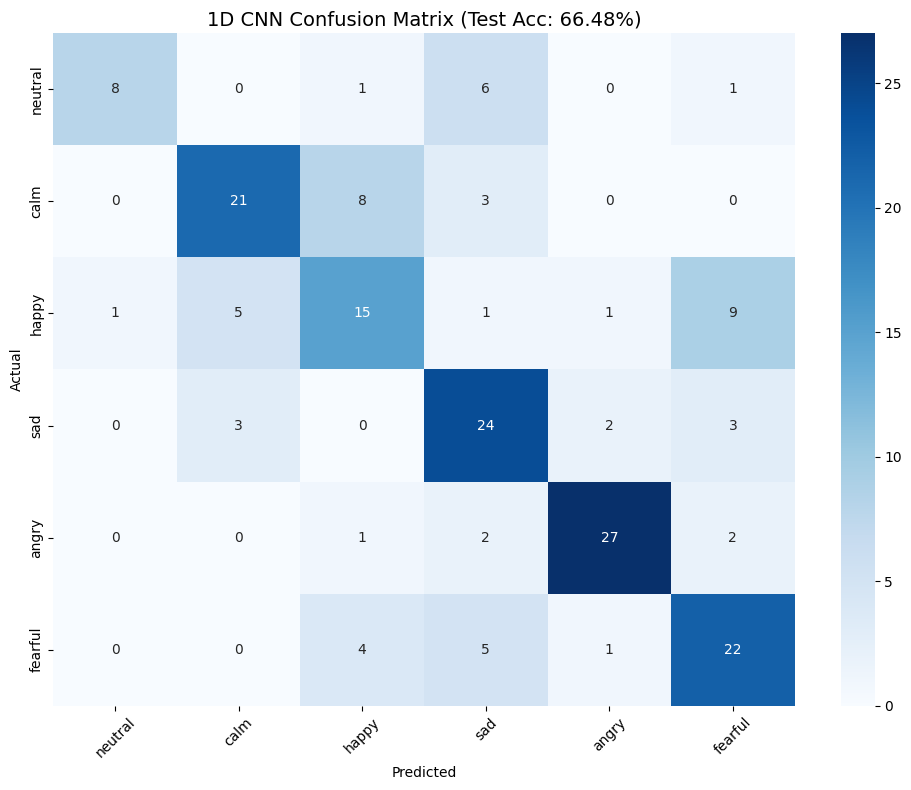

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=settings.EMOTION_NAMES,
            yticklabels=settings.EMOTION_NAMES, ax=ax)
ax.set_title(f'1D CNN Confusion Matrix (Test Acc: {test_acc*100:.2f}%)', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(settings.FIGURES_DIR / "fig07-cnn1d_confusion_matrix.png", dpi=150, bbox_inches="tight")
print(f"Saved confusion matrix to {settings.FIGURES_DIR / 'fig07-cnn1d_confusion_matrix.png'}")
plt.show()

## Per-emotion accuracy breakdown

In [10]:
per_class = {}
print(f"\n{'emotion':<12} {'support':>8} {'correct':>8} {'acc':>8}")
for i, name in enumerate(settings.EMOTION_NAMES):
    mask = y_test == i
    total = int(mask.sum())
    correct = int((test_preds[mask] == i).sum())
    acc = correct / total * 100 if total else 0.0
    per_class[name] = {"support": total, "correct": correct, "acc": round(acc / 100, 4)}
    print(f"{name:<12} {total:>8d} {correct:>8d} {acc:>7.1f}%")


emotion       support  correct      acc
neutral            16        8    50.0%
calm               32       21    65.6%
happy              32       15    46.9%
sad                32       24    75.0%
angry              32       27    84.4%
fearful            32       22    68.8%


## CPU inference latency benchmark (production deployment target)

the project-defined target is cpu deployment. measure per-sample latency on cpu (not the training device). we reload a fresh copy of the model onto cpu to time the deployment scenario.

In [11]:
cpu_model = load_cnn(settings.MODELS_DIR / "cnn1d_best.pth", device='cpu')
cpu_stats = cpu_inference_latency(
    cpu_model,
    n_mels=settings.N_MELS,
    time_frames=settings.N_MELS_FRAMES,
    n_runs=200,
    device='cpu',
)

**print cnn cpu latency**. the cnn averages 0.53ms per sample with ~1888 samples/second throughput. still very fast, but about 2.7x slower than the svm.

In [12]:
print(f"1D CNN CPU inference latency (batch=1, n_runs={cpu_stats['n_runs']}):")
print(f"  mean: {cpu_stats['mean_ms']:.2f} ms/sample")
print(f"  std:  {cpu_stats['std_ms']:.2f} ms")
print(f"  p50:  {cpu_stats['p50_ms']:.2f} ms")
print(f"  p99:  {cpu_stats['p99_ms']:.2f} ms")
print(f"  throughput (single-sample): {1000.0 / cpu_stats['mean_ms']:.0f} samples/s")

1D CNN CPU inference latency (batch=1, n_runs=200):
  mean: 0.53 ms/sample
  std:  0.10 ms
  p50:  0.50 ms
  p99:  0.86 ms
  throughput (single-sample): 1888 samples/s


## Save results to JSON (consumed by 08)

In [13]:
results = {
    "model":      "cnn1d",
    "split":      "test",
    "n_samples":  int(len(y_test)),
    "accuracy":   float(test_acc),
    "per_class":  per_class,
    "confusion_matrix": cm.tolist(),
    "emotion_names":    list(settings.EMOTION_NAMES),
    "parameters": int(params),
    "speakers":   list(settings.TEST_ACTORS),
    "cpu_latency": {
        "mean_ms": float(cpu_stats['mean_ms']),
        "std_ms":  float(cpu_stats['std_ms']),
        "p50_ms":  float(cpu_stats['p50_ms']),
        "p99_ms":  float(cpu_stats['p99_ms']),
        "n_runs":  int(cpu_stats['n_runs']),
        "device":  'cpu',
    },
}
print(json.dumps(results, indent=4))

{
    "model": "cnn1d",
    "split": "test",
    "n_samples": 176,
    "accuracy": 0.6647727272727273,
    "per_class": {
        "neutral": {
            "support": 16,
            "correct": 8,
            "acc": 0.5
        },
        "calm": {
            "support": 32,
            "correct": 21,
            "acc": 0.6562
        },
        "happy": {
            "support": 32,
            "correct": 15,
            "acc": 0.4688
        },
        "sad": {
            "support": 32,
            "correct": 24,
            "acc": 0.75
        },
        "angry": {
            "support": 32,
            "correct": 27,
            "acc": 0.8438
        },
        "fearful": {
            "support": 32,
            "correct": 22,
            "acc": 0.6875
        }
    },
    "confusion_matrix": [
        [
            8,
            0,
            1,
            6,
            0,
            1
        ],
        [
            0,
            21,
            8,
            3,
          

**ensure predictions directory**. create if needed.

In [14]:
results_path = settings.PREDICTIONS_DIR / "test_results_cnn.json"
results_path.parent.mkdir(parents=True, exist_ok=True)

**save test results to json**. persist for comparison notebook.

In [15]:
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved test results to {results_path}")

Saved test results to E:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets\data\predictions\test_results_cnn.json
